In [1]:
# Import necessary libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import glob
import random

# Function to open an npz file
def open_npz_file(npz_path):
    """Open an npz file and return the chip and metadata"""
    try:
        archive = np.load(npz_path, allow_pickle=True)
        chip = archive['chip']
        # data = archive['data'].item() # Metadata if needed
        print(f"File: {os.path.basename(npz_path)}")
        print(f"Chip Shape (T, H, W, C): {chip.shape}")
        return chip
    except Exception as e:
        print(f"Error opening {npz_path}: {str(e)}")
        return None

In [2]:
# Function to find all npz files in a directory
def find_npz_files(directory_path):
    """Find all .npz files in a directory"""
    npz_pattern = os.path.join(directory_path, "*.npz")
    npz_files = glob.glob(npz_pattern)
    npz_files.sort()  # Sort files for consistent ordering
    return npz_files

# Function to enhance image contrast
def enhance_contrast(data, enhancement_factor=3.0):
    """Apply contrast enhancement to an image band"""
    # Handle potential NaN or Inf
    valid_mask = np.isfinite(data)
    valid_data = data[valid_mask]
    
    if len(valid_data) == 0:
        return np.zeros_like(data)
    
    p_low = max(0, 50 - enhancement_factor * 25)
    p_high = min(100, 50 + enhancement_factor * 25)
    
    vmin = np.nanpercentile(valid_data, p_low)
    vmax = np.nanpercentile(valid_data, p_high)
    
    if vmin == vmax:
        vmin = vmin - 0.1
        vmax = vmax + 0.1
    
    normalized = (data - vmin) / (vmax - vmin)
    return np.clip(normalized, 0, 1)


In [3]:
# Function to create RGB composites for all timesteps
def visualize_all_timesteps(chip, rgb_bands=[0, 1, 4], 
                          enhancement=3.0, figsize=(15, 10)):
    """
    Create and display RGB composites for all timesteps from a chip array
    
    Parameters:
    - chip: numpy array of shape (T, H, W, C)
    - rgb_bands: list of three band indices to use [r_idx, g_idx, b_idx]
    - enhancement: contrast enhancement factor
    - figsize: figure size
    """
    n_times = chip.shape[0]
    
    # Create a grid of subplots
    n_cols = 3
    n_rows = (n_times + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    
    # Handle the case where axes might not be an array (if n_times=1)
    if n_times == 1:
        axes_flat = [axes]
    else:
        axes_flat = axes.flatten()
    
    # Process each timestep
    for t in range(n_times):
        try:
            # Extract the three bands for this timestep
            # chip shape is (T, H, W, C)
            band_data = [
                chip[t, :, :, b] for b in rgb_bands
            ]
            
            # Calculate min and max values for the raw data (for title)
            all_vals = np.concatenate([b.flatten() for b in band_data])
            valid_vals = all_vals[np.isfinite(all_vals)]
            
            if len(valid_vals) > 0:
                data_min, data_max = np.min(valid_vals), np.max(valid_vals)
            else:
                data_min = data_max = 0
            
            # Apply contrast enhancement
            enhanced_bands = [enhance_contrast(band, enhancement) for band in band_data]
            
            # Create RGB composite
            rgb = np.stack(enhanced_bands, axis=-1)
            
            # Display the image
            axes_flat[t].imshow(rgb)
            
            title = f"Timestep {t}\nMin: {data_min:.3f}, Max: {data_max:.3f}"
            axes_flat[t].set_title(title, fontsize=10)
            axes_flat[t].axis('off')
            
        except Exception as e:
            print(f"Error processing timestep {t}: {str(e)}")
            axes_flat[t].text(0.5, 0.5, f"Error: {str(e)[:50]}...", 
                            ha='center', va='center', transform=axes_flat[t].transAxes)
            axes_flat[t].axis('off')
    
    # Hide any unused subplots
    for i in range(n_times, len(axes_flat)):
        axes_flat[i].axis('off')
        axes_flat[i].set_visible(False)
    
    plt.suptitle(f"RGB Composites (R: Band {rgb_bands[0]+1}, G: Band {rgb_bands[1]+1}, B: Band {rgb_bands[2]+1})",
               fontsize=16)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()


In [4]:
# Function to process multiple npz files
def process_multiple_npz_files(directory_path, rgb_bands=[0, 1, 4], enhancement=3.0, max_files=5):
    """Process npz files in a directory"""
    
    npz_files = find_npz_files(directory_path)
    
    if not npz_files:
        print(f"No .npz files found in {directory_path}")
        return
    
    # Select a random sample of files each time
    num_to_select = min(max_files, len(npz_files))
    files_to_process = random.sample(npz_files, num_to_select)
    
    print(f"Found {len(npz_files)} npz files. Processing {len(files_to_process)} random samples:")
    
    for npz_file in files_to_process:
        print(f"\n{'='*60}")
        
        chip = open_npz_file(npz_file)
        
        if chip is not None:
            visualize_all_timesteps(
                chip, 
                rgb_bands=rgb_bands,
                enhancement=enhancement,
                figsize=(16, 12)
            )


VISUALIZING NPZ CHIPS
Found 661 npz files. Processing 1 random samples:

File: 2020-001-72864_3523-3222-16240.npz
Chip Shape (T, H, W, C): (5, 128, 128, 16)


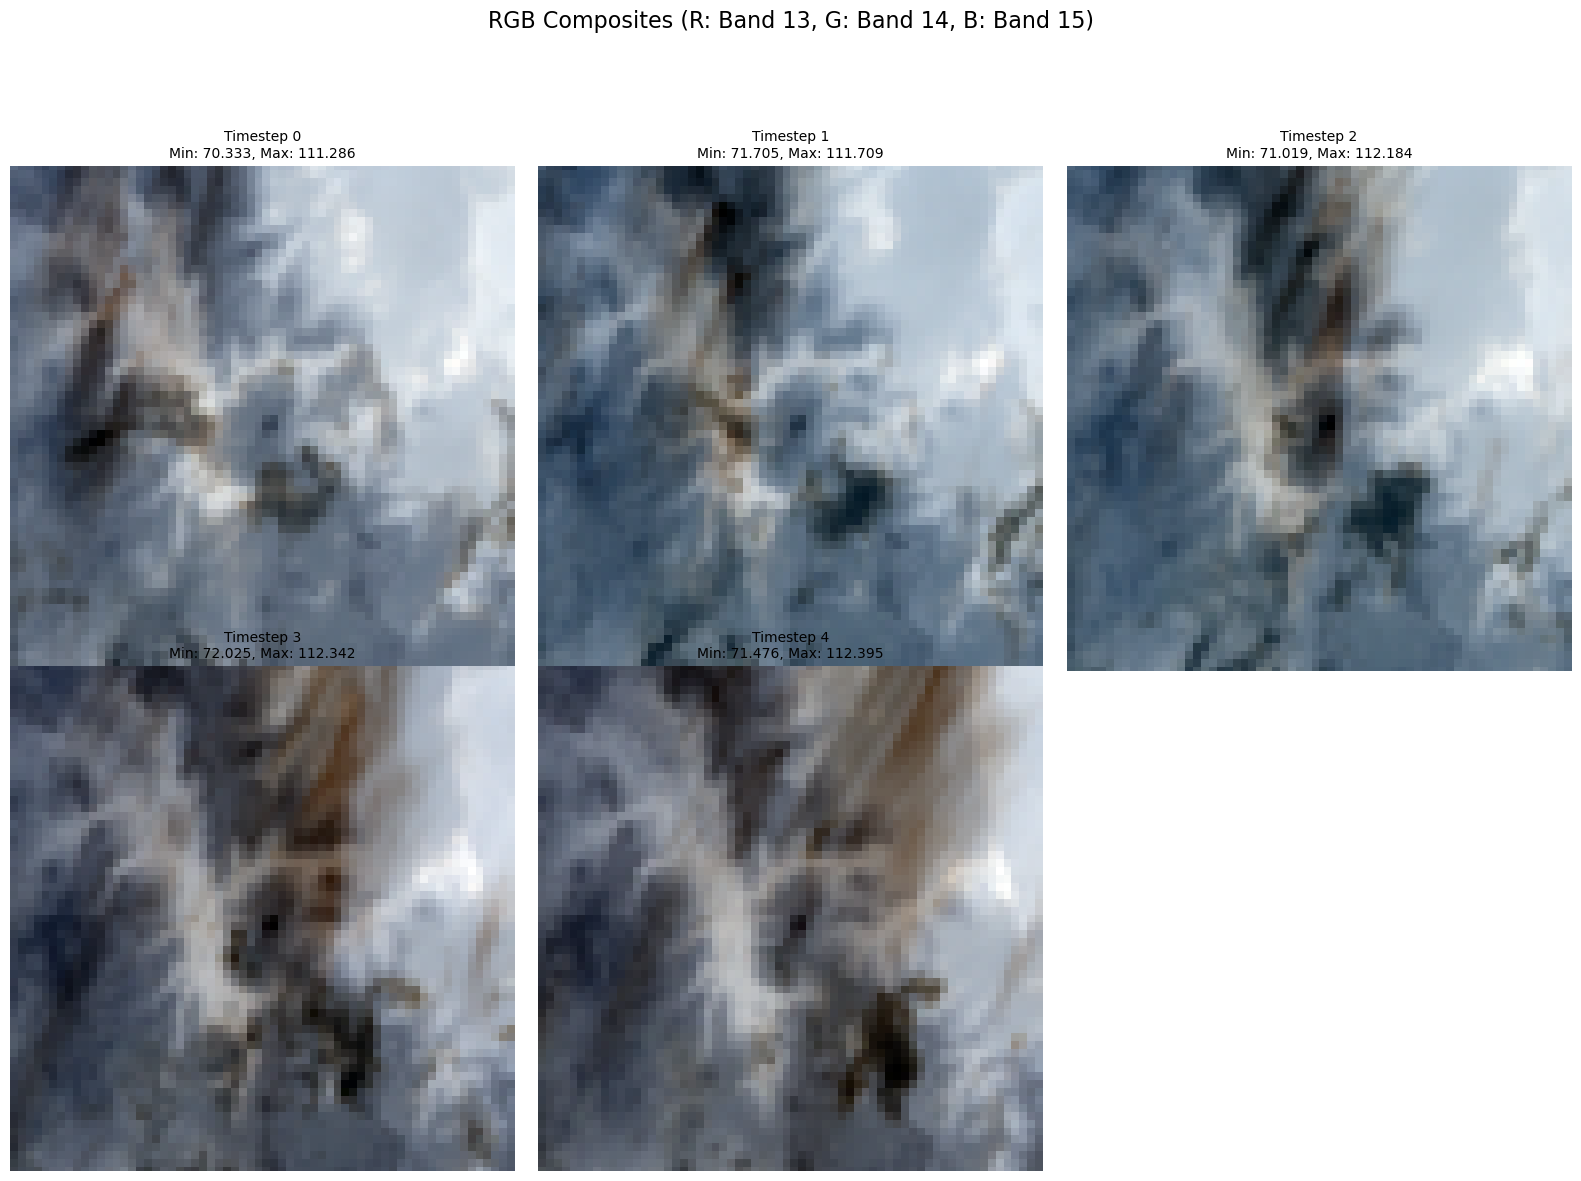

In [11]:
# Path to the output folder generated by your script
output_directory = '/home/al8425b-hpc/NASA/satvision-pix4d/examples/abi_3d_reconstruction/originalChipTest/output'

print("VISUALIZING NPZ CHIPS")
print("="*60)

process_multiple_npz_files(
    directory_path=output_directory,
    # Using Thermal Infrared bands for better cloud visualization:
    # Band 13 (Index 12), Band 14 (Index 13), Band 15 (Index 14)
    rgb_bands=[12, 13, 14], 
    enhancement=3.0,
    max_files=1
)